# Data Exploration

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import glob


sys.path.append(os.path.abspath("../scripts"))

from evaluate import evaluate_model

# Import modules
import config
import feature_engineering
import data_pipeline
import model_training
import plots
from evaluate import evaluate_model

# Function to reload all custom modules (use when needed)
def reload_modules():
    """Reload all custom modules for development"""
    importlib.reload(config)
    importlib.reload(feature_engineering)
    importlib.reload(data_pipeline)
    importlib.reload(model_training)
    importlib.reload(plots)
    print("All modules reloaded!")

In [9]:
df = data_pipeline.load_data("03-06-24", "A1.csv")
df.columns.values

array(['mode', 'ox/red', 'error', 'control changes', 'Ns changes',
       'counter inc.', 'Ns', 'I Range', 'time/s', 'control/V/mA',
       'Ecell/V', 'I/mA', 'dq/mA.h', '(Q-Qo)/mA.h', '|Energy|/W.h',
       'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'Q charge/discharge/mA.h',
       'half cycle', 'Energy charge/W.h', 'Energy discharge/W.h',
       'Capacitance charge/µF', 'Capacitance discharge/µF', 'step time/s',
       'z cycle', 'Re(Z)/Ohm', 'Im(Z)/Ohm', 'Re(Y)/Ohm-1', 'Im(Y)/Ohm-1',
       '|Y|/Ohm-1', 'Phase(Y)/deg', 'x', 'Q discharge/mA.h',
       'Q charge/mA.h', 'Capacity/mA.h', 'Efficiency/%', 'control/V',
       'control/mA', 'cycle number', 'P/W', 'R/Ohm'], dtype=object)

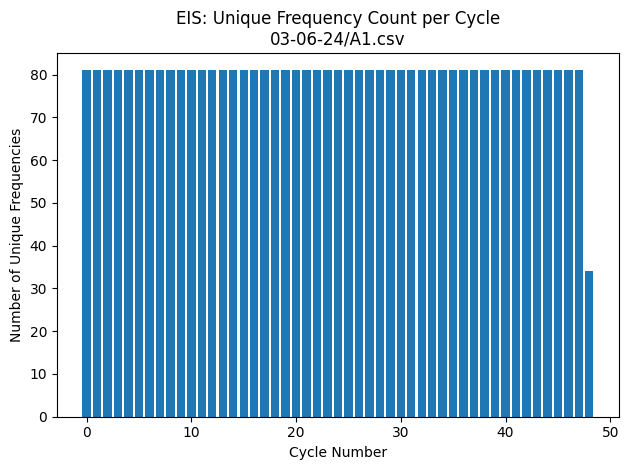

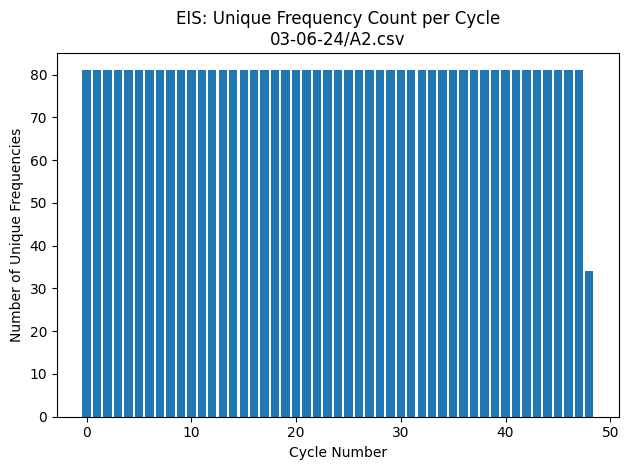

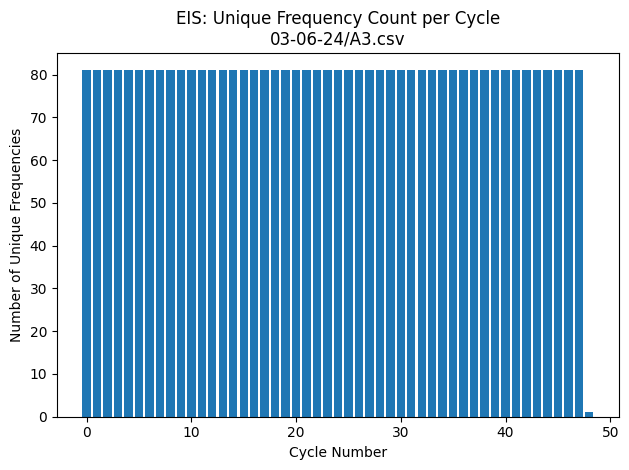

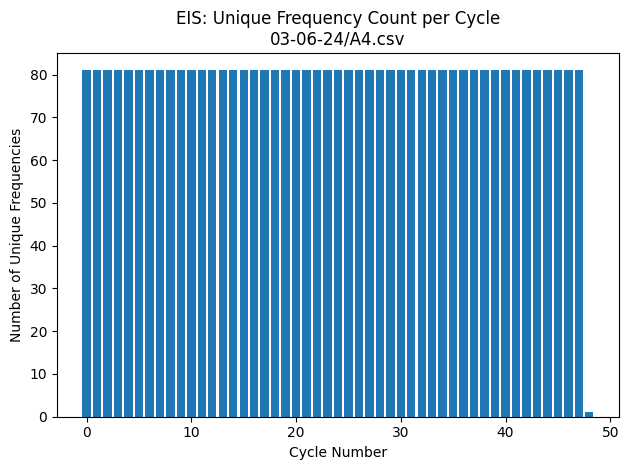

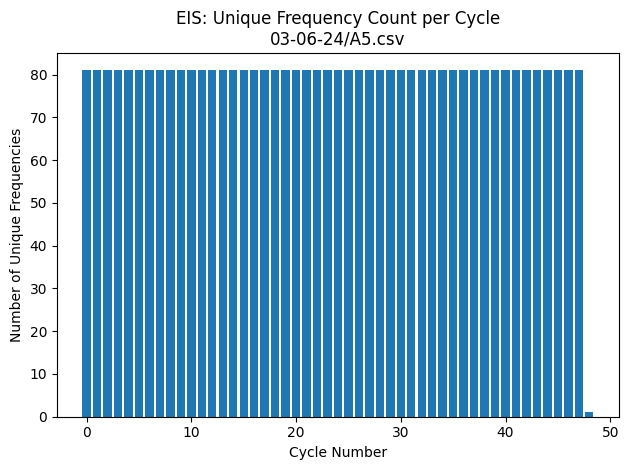

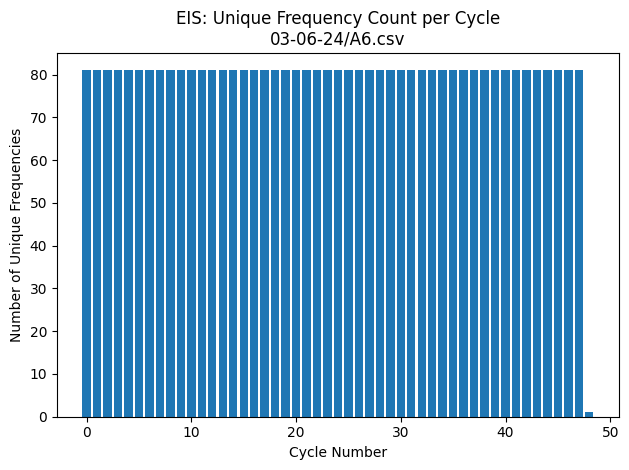

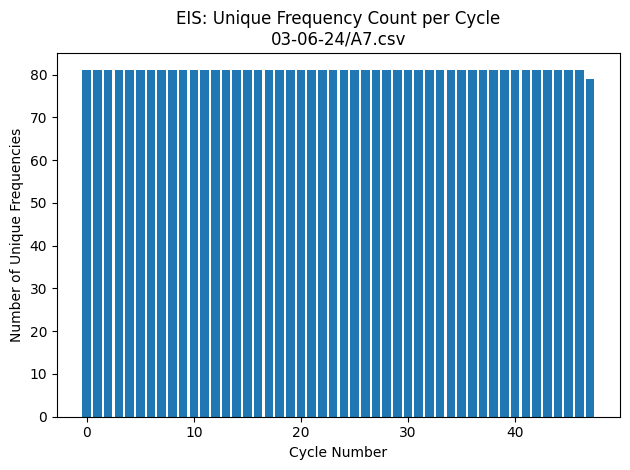

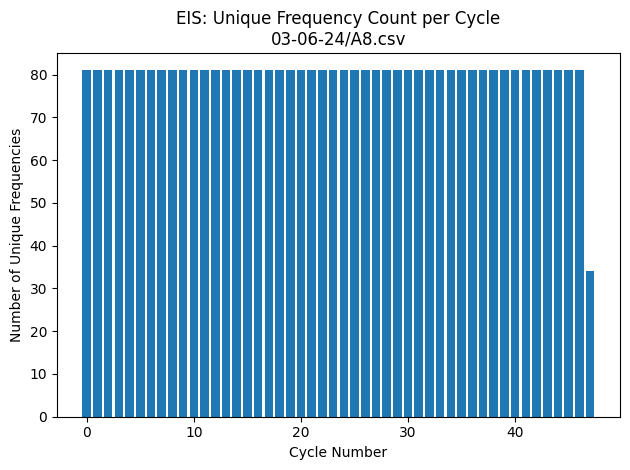

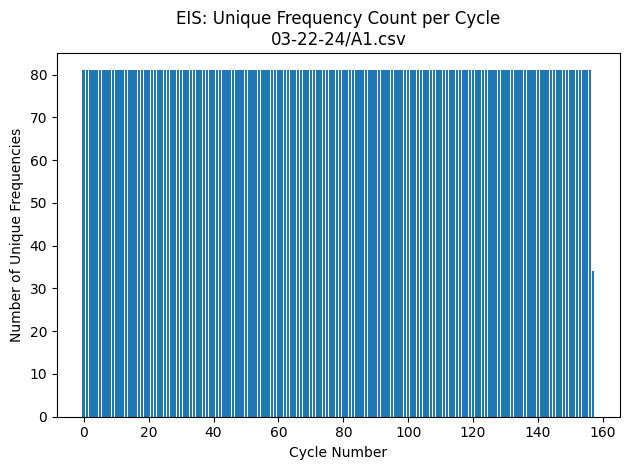

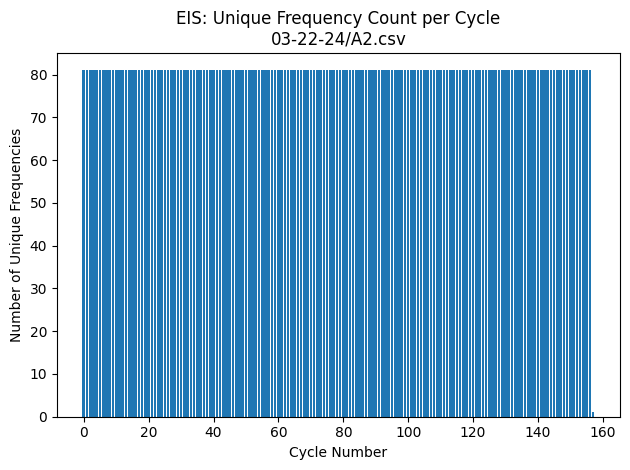

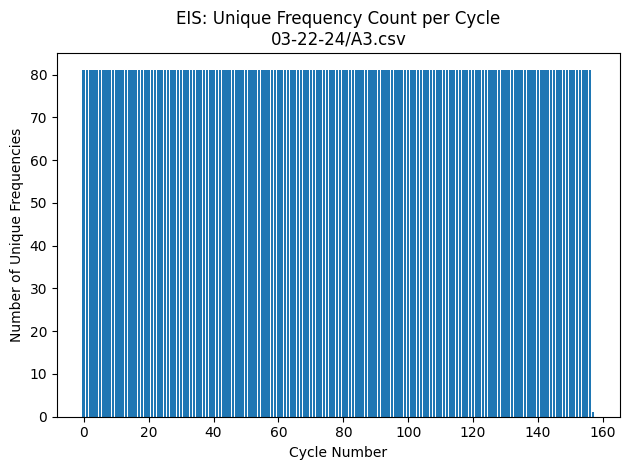

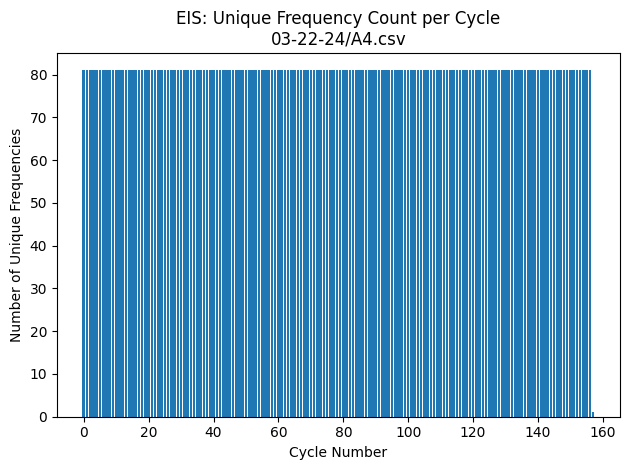

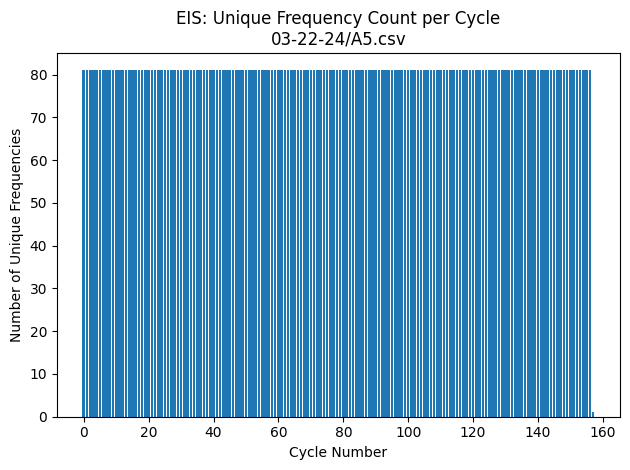

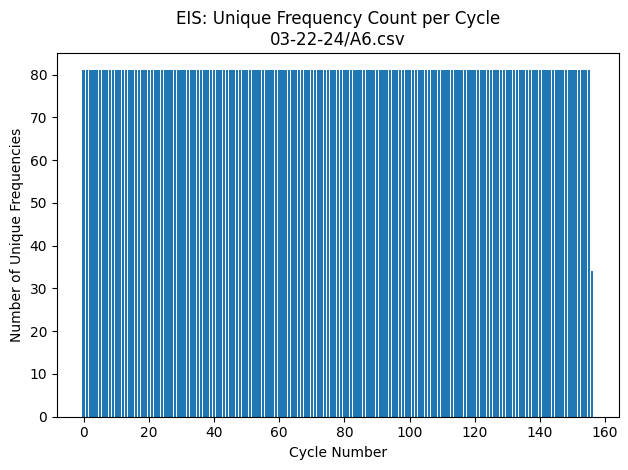

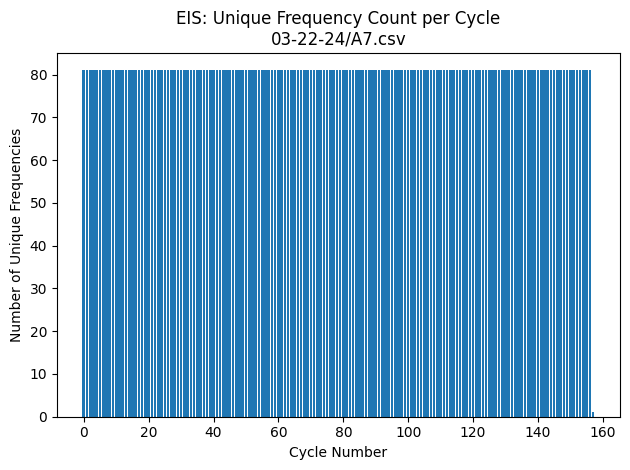

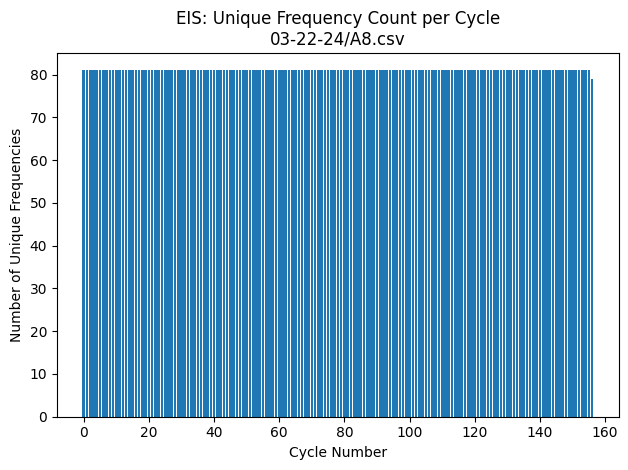

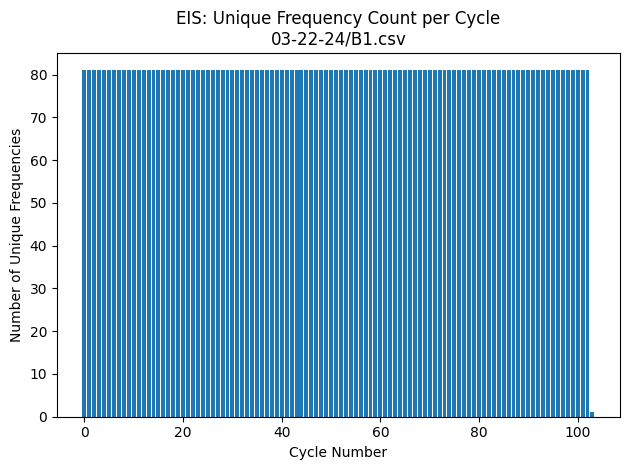

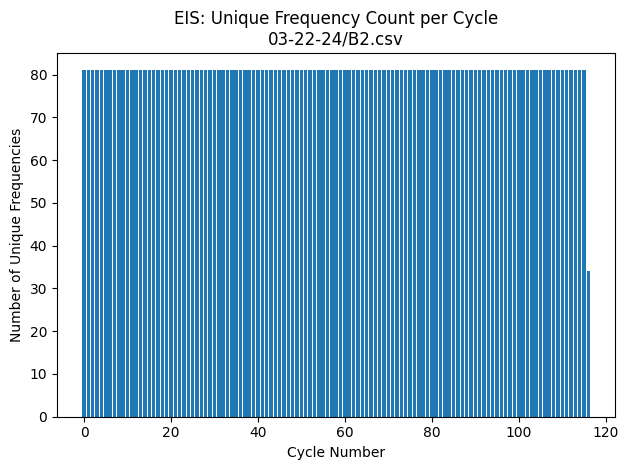

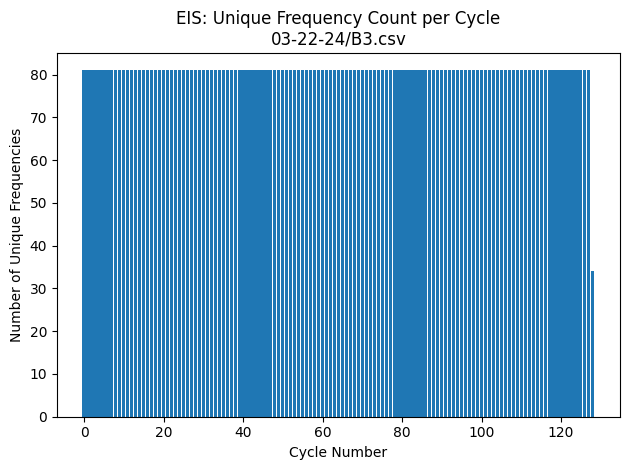

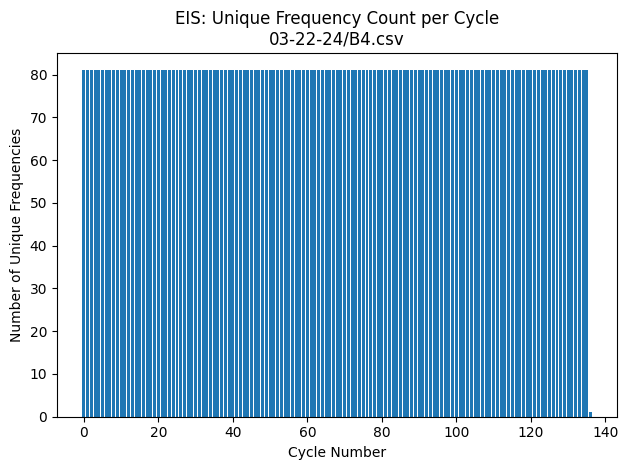

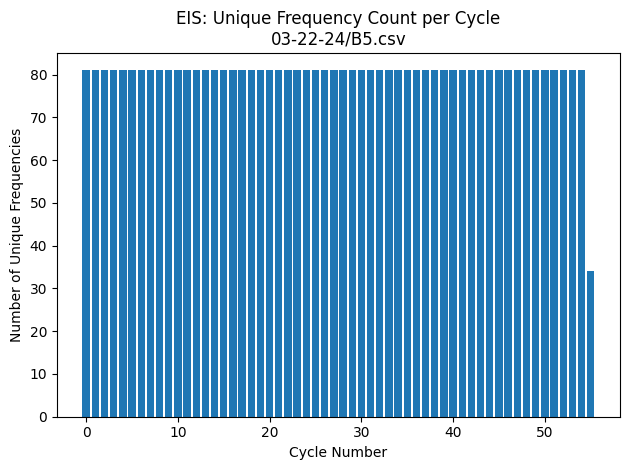

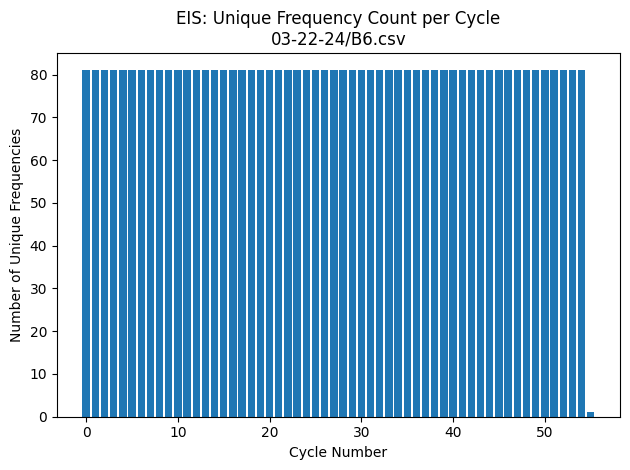

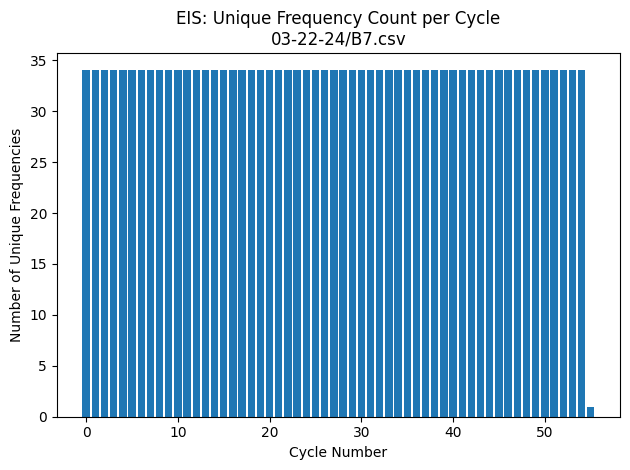

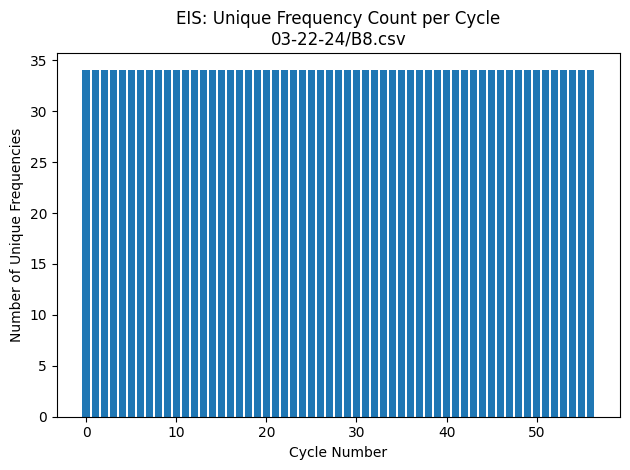

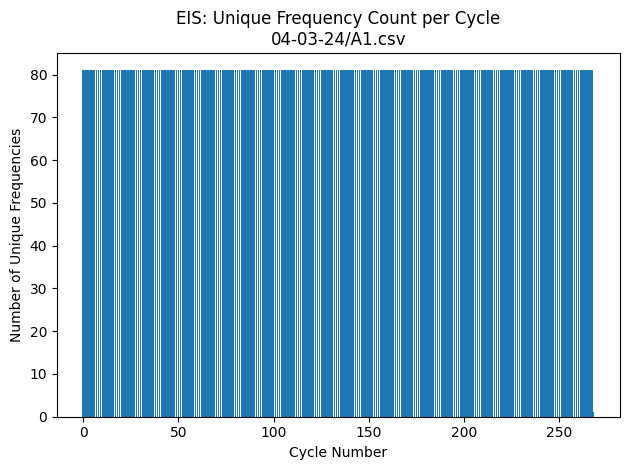

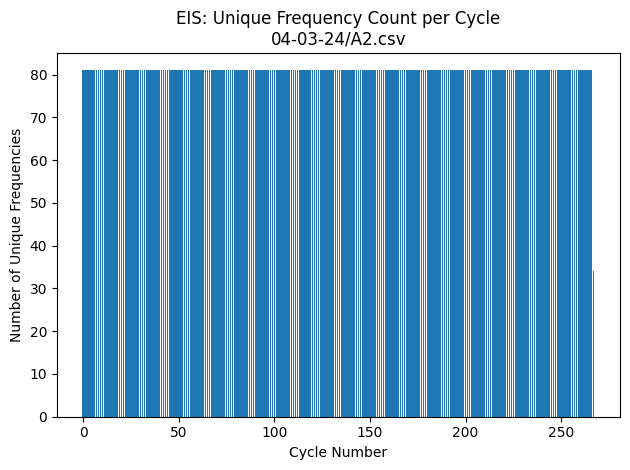

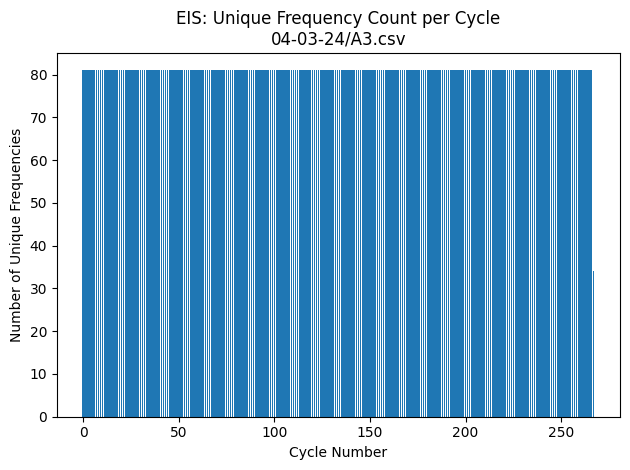

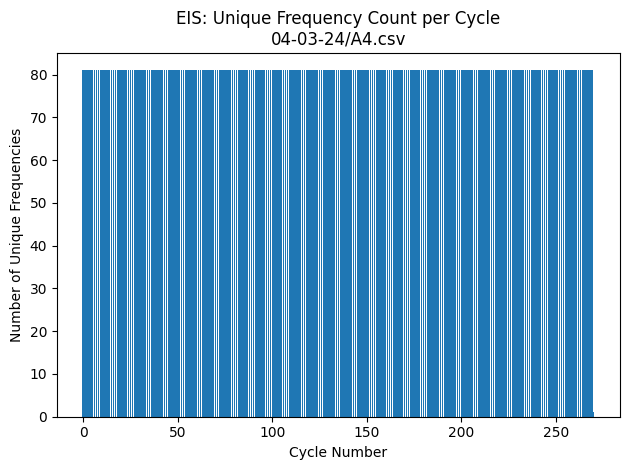

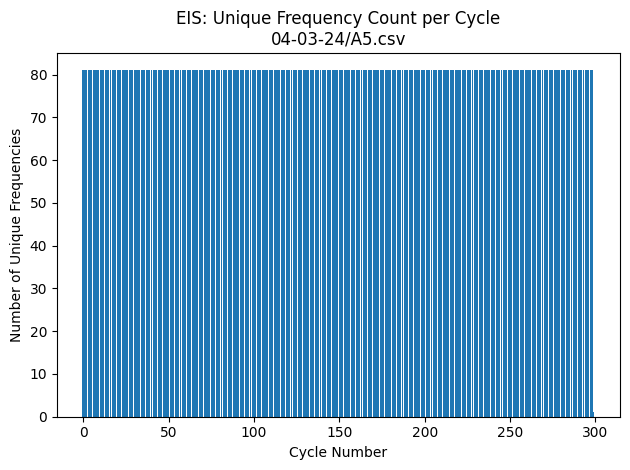

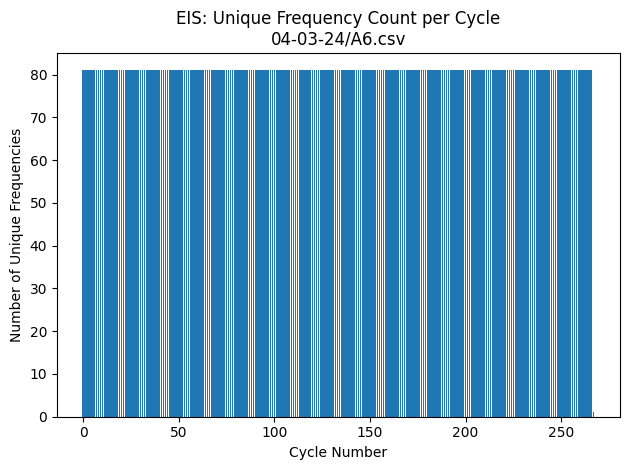

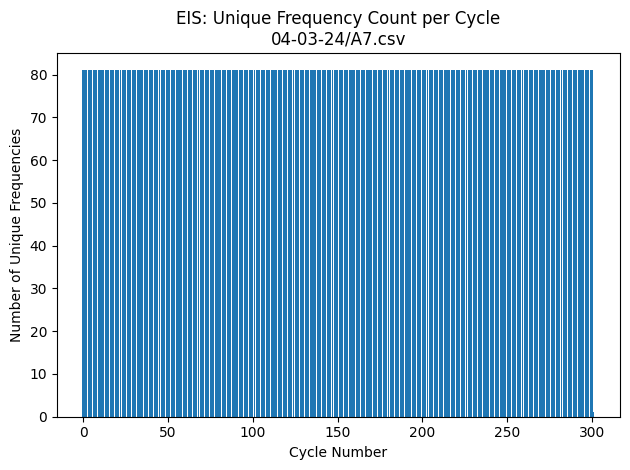

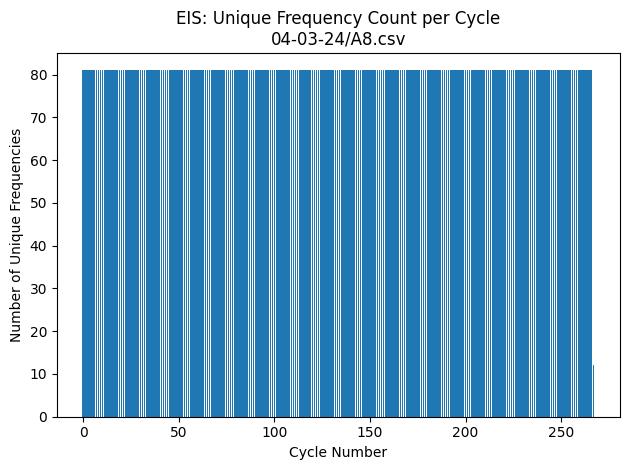

In [4]:
# Adjust this to point at the parent folder that contains your date-folders
data_root = "../data"

for folder in sorted(os.listdir(data_root)):
    folder_path = os.path.join(data_root, folder)
    if not os.path.isdir(folder_path):
        continue

    for filename in sorted(os.listdir(folder_path)):
        if not filename.lower().endswith('.csv'):
            continue

        # 1) Load
        df = data_pipeline.load_data(folder, filename)

        # 2) Compute unique-frequency count per cycle
        freq_counts = (
            df
            .groupby('cycle number')['freq/Hz']
            .nunique()
            .reset_index(name='unique_freq_count')
        )

        # 3) Plot
        plt.figure()
        plt.bar(freq_counts['cycle number'], freq_counts['unique_freq_count'])
        plt.xlabel('Cycle Number')
        plt.ylabel('Number of Unique Frequencies')
        plt.title(f'EIS: Unique Frequency Count per Cycle\n{folder}/{filename}')
        plt.tight_layout()
        plt.show()


In [38]:
df_cycle = df[df['cycle number'] == 1].copy()

df_charge = df_cycle[df_cycle['I/mA'] > 0].copy() 
df_discharge = df_cycle[df_cycle['I/mA'] < 0].copy()     # DataFrame for discharging steps.

In [39]:
df_charge[['cycle number', 'I/mA']]

,cycle number,I/mA
336,1.0,8000.0
337,1.0,8020.0
338,1.0,8000.0
339,1.0,7990.0
340,1.0,8000.0
...,...,...
621,1.0,219.0
626,1.0,118.0
627,1.0,268.0
628,1.0,191.0


In [40]:
df_discharge[['cycle number', 'I/mA']]

,cycle number,I/mA
456,1.0,-114.0
457,1.0,-140.0
459,1.0,-525.0
461,1.0,-695.0
462,1.0,-718.0
...,...,...
624,1.0,-346.0
625,1.0,-110.0
630,1.0,-108.0
631,1.0,-170.0


## Preprocess for exploration

In [ ]:
df = data_pipeline.load_data("03-22-24", "A4.csv")

df = df[(df['freq/Hz'] > 0.2) & (df['freq/Hz'] <= 20000)]
unique_freqs = np.array(df['freq/Hz'].unique())
unique_freqs.sort()

print(unique_freqs)

[2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.76e+01 7.50e+01 9.06e+01 1.02e+02 1.22e+02 1.35e+02
 1.63e+02 1.78e+02 2.19e+02 2.37e+02 2.94e+02 3.16e+02 3.94e+02 4.22e+02
 5.29e+02 5.64e+02 7.10e+02 7.50e+02 9.52e+02 1.00e+03 1.28e+03 1.33e+03
 1.71e+03 1.78e+03 2.30e+03 2.37e+03 3.09e+03 3.16e+03 4.14e+03 4.22e+03
 5.56e+03 5.62e+03 7.45e+03 7.50e+03 1.00e+04]


In [71]:
unique_counts_by_cycle = {}

# Get a sorted list of unique cycle numbers.
all_cycles = sorted(df['cycle number'].unique())

# Loop through each cycle, count, and print the unique frequencies.
for cycle in all_cycles:
    # Filter the DataFrame for the current cycle and count unique frequencies
    unique_count = len(np.unique(df[df['cycle number'] == cycle]['freq/Hz']))
    unique_counts_by_cycle[cycle] = unique_count
    print(f"Cycle {cycle} has {unique_count} unique frequency points.")


Cycle 0.0 has 69 unique frequency points.
Cycle 1.0 has 69 unique frequency points.
Cycle 2.0 has 69 unique frequency points.
Cycle 3.0 has 69 unique frequency points.
Cycle 4.0 has 69 unique frequency points.
Cycle 5.0 has 69 unique frequency points.
Cycle 6.0 has 69 unique frequency points.
Cycle 7.0 has 69 unique frequency points.
Cycle 8.0 has 69 unique frequency points.
Cycle 9.0 has 69 unique frequency points.
Cycle 10.0 has 69 unique frequency points.
Cycle 11.0 has 69 unique frequency points.
Cycle 12.0 has 69 unique frequency points.
Cycle 13.0 has 69 unique frequency points.
Cycle 14.0 has 69 unique frequency points.
Cycle 15.0 has 69 unique frequency points.
Cycle 16.0 has 69 unique frequency points.
Cycle 17.0 has 69 unique frequency points.
Cycle 18.0 has 69 unique frequency points.
Cycle 19.0 has 69 unique frequency points.
Cycle 20.0 has 69 unique frequency points.
Cycle 21.0 has 69 unique frequency points.
Cycle 22.0 has 69 unique frequency points.
Cycle 23.0 has 69 uni

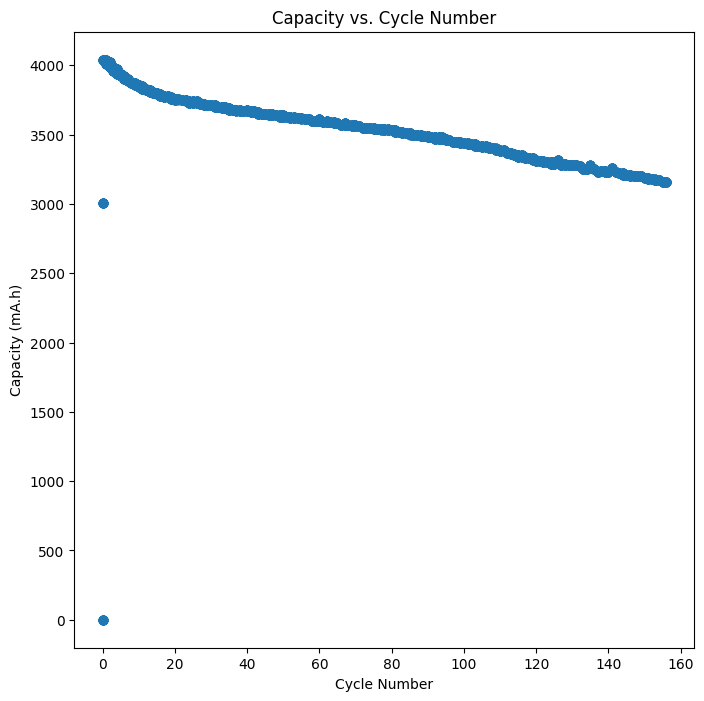

In [72]:
plot_degradation(df)

In [43]:
filtered_df=df[df['cycle number'] == 1]

In [44]:
unique_freqs_by_cycle = {}

all_cycles = sorted(df['cycle number'].unique())
for cycle in all_cycles:
    cycle_freqs = np.sort(df[df['cycle number'] == cycle]['freq/Hz'].unique())
    unique_freqs_by_cycle[cycle] = cycle_freqs
    print(f"Cycle {cycle} frequency points: {cycle_freqs}")

# Compute the intersection of frequency sets
common_freqs = set(unique_freqs_by_cycle[all_cycles[0]])
for cycle in all_cycles:
    common_freqs = common_freqs.intersection(set(unique_freqs_by_cycle[cycle]))

print("Common frequency points across all cycles:", np.sort(list(common_freqs)))


Cycle 0.0 frequency points: [2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.76e+01 7.50e+01 9.06e+01 1.02e+02 1.22e+02 1.35e+02
 1.63e+02 1.78e+02 2.19e+02 2.37e+02 2.94e+02 3.16e+02 3.94e+02 4.22e+02
 5.29e+02 5.64e+02 7.10e+02 7.50e+02 9.52e+02 1.00e+03 1.28e+03 1.33e+03
 1.71e+03 1.78e+03 2.30e+03 2.37e+03 3.09e+03 3.16e+03 4.14e+03 4.22e+03
 5.56e+03 5.62e+03 7.45e+03 7.50e+03 1.00e+04]
Cycle 1.0 frequency points: [2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.

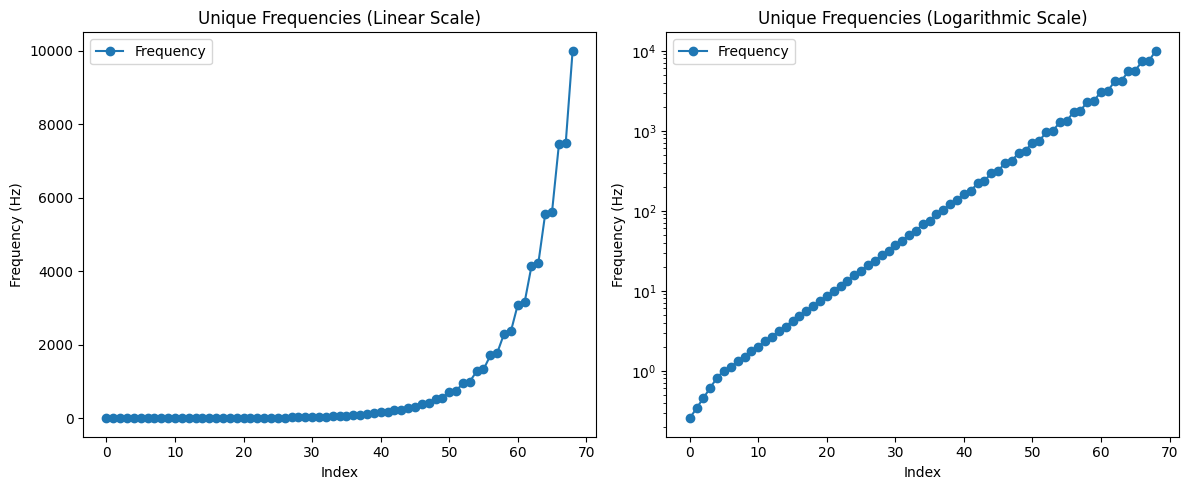

In [45]:
plot_unique_frequencies(unique_freqs)

## Action Vector Analysis
Let's explore what we can extract for a more comprehensive action vector that follows the paper's methodology.

In [8]:
# Let's analyze what Ns values we have and what they represent
import pandas as pd
import numpy as np

# Load data directly
df = pd.read_csv("../data/03-06-24/A1.csv")
df = df.dropna()

# Fix column name issue if needed
if '#NAME?' in df.columns:
    df = df.rename(columns={'#NAME?': 'Im(Z)/Ohm'})

# Remove cycle 0 
df = df[df['cycle number'] != 0]

# Look at unique Ns values and their characteristics
print("Analysis by Ns step:")
for ns in sorted(df['Ns'].unique()):
    ns_data = df[df['Ns'] == ns]
    print(f"\nNs = {ns}:")
    print(f"  I/mA range: {ns_data['I/mA'].min():.3f} to {ns_data['I/mA'].max():.3f} (avg: {ns_data['I/mA'].mean():.3f})")
    print(f"  Time range: {ns_data['time/s'].min():.1f} to {ns_data['time/s'].max():.1f} seconds")
    print(f"  ox/red modes: {sorted(ns_data['ox/red'].unique())}")
    print(f"  Control voltage: {ns_data['control/V'].mean():.3f}V (±{ns_data['control/V'].std():.3f})")
    print(f"  Number of data points: {len(ns_data)}")
    
    # Show what type of step this is
    if ns_data['I/mA'].mean() > 1:
        print(f"  -> This appears to be a CHARGING step")
    elif ns_data['I/mA'].mean() < -1:
        print(f"  -> This appears to be a DISCHARGING step")
    elif ns in [1, 6]:
        print(f"  -> This is an EIS measurement step")
    else:
        print(f"  -> This appears to be a rest/equilibration step")

Analysis by Ns step:

Ns = 1.0:
  I/mA range: -800.000 to 762.000 (avg: -23.275)
  Time range: 19600.0 to 421000.0 seconds
  ox/red modes: [np.float64(0.0), np.float64(1.0)]
  Control voltage: 2.810V (±0.019)
  Number of data points: 2256
  -> This appears to be a DISCHARGING step

Ns = 2.0:
  I/mA range: 0.000 to 0.000 (avg: 0.000)
  Time range: 20500.0 to 421000.0 seconds
  ox/red modes: [np.float64(0.0)]
  Control voltage: 0.000V (±0.000)
  Number of data points: 47
  -> This appears to be a rest/equilibration step

Ns = 3.0:
  I/mA range: 7990.000 to 8020.000 (avg: 7999.869)
  Time range: 11100.0 to 422000.0 seconds
  ox/red modes: [np.float64(0.0), np.float64(1.0)]
  Control voltage: 0.000V (±0.000)
  Number of data points: 2216
  -> This appears to be a CHARGING step

Ns = 4.0:
  I/mA range: 398.000 to 8030.000 (avg: 2592.939)
  Time range: 12600.0 to 424000.0 seconds
  ox/red modes: [np.float64(1.0)]
  Control voltage: 4.200V (±0.000)
  Number of data points: 2091
  -> This appe

In [9]:
# Now let's look at a specific cycle to understand the charge/discharge protocol
cycle_num = 1
cycle_data = df[df['cycle number'] == cycle_num].copy()

print(f"\nDetailed analysis for Cycle {cycle_num}:")
print("Ns step sequence:")
for ns in cycle_data['Ns'].unique():
    ns_data = cycle_data[cycle_data['Ns'] == ns]
    current_range = f"{ns_data['I/mA'].min():.3f} to {ns_data['I/mA'].max():.3f}"
    duration = ns_data['step time/s'].iloc[-1] if not ns_data.empty else 0
    ox_red = ns_data['ox/red'].iloc[0] if not ns_data.empty else "Unknown"
    control_v = ns_data['control/V'].mean()
    
    print(f"  Ns={ns}: {ox_red}, I/mA: {current_range}, Duration: {duration:.1f}s, Control: {control_v:.3f}V")


Detailed analysis for Cycle 1:
Ns step sequence:
  Ns=3.0: 0.0, I/mA: 7990.000 to 8000.000, Duration: 1420.0s, Control: 0.000V
  Ns=4.0: 1.0, I/mA: 400.000 to 8030.000, Duration: 2610.0s, Control: 4.200V
  Ns=5.0: 1.0, I/mA: 0.000 to 0.000, Duration: 3480.0s, Control: 0.000V
  Ns=6.0: 0.0, I/mA: -693.000 to 783.000, Duration: 5670.0s, Control: 4.170V
  Ns=7.0: 1.0, I/mA: 0.000 to 0.000, Duration: 6540.0s, Control: 0.000V
  Ns=8.0: 1.0, I/mA: -15000.000 to -14900.000, Duration: 970.0s, Control: 0.000V
  Ns=9.0: 0.0, I/mA: 0.000 to 0.000, Duration: 1840.0s, Control: 0.000V
  Ns=1.0: 0.0, I/mA: -750.000 to 716.000, Duration: 2790.0s, Control: 2.730V
  Ns=2.0: 0.0, I/mA: 0.000 to 0.000, Duration: 2790.0s, Control: 0.000V


In [10]:
# Let's analyze the charge and discharge characteristics that could form a better action vector
def analyze_cycle_protocol(df, cycle_num):
    """Analyze charge/discharge protocol for a specific cycle"""
    cycle_data = df[df['cycle number'] == cycle_num].copy()
    
    # Separate charge and discharge steps (excluding EIS)
    charge_steps = cycle_data[(cycle_data['I/mA'] > 0) & (~cycle_data['Ns'].isin([1, 6]))]
    discharge_steps = cycle_data[(cycle_data['I/mA'] < 0) & (~cycle_data['Ns'].isin([1, 6]))]
    
    action_features = {}
    
    # Charge characteristics
    if not charge_steps.empty:
        action_features['charge_current_avg'] = charge_steps['I/mA'].mean()
        action_features['charge_current_max'] = charge_steps['I/mA'].max()
        action_features['charge_voltage_avg'] = charge_steps['Ecell/V'].mean()
        action_features['charge_voltage_max'] = charge_steps['Ecell/V'].max()
        action_features['charge_duration'] = charge_steps['step time/s'].sum()
        action_features['charge_energy'] = charge_steps['Energy charge/W.h'].sum()
        action_features['total_charge_capacity'] = charge_steps['Q charge/mA.h'].max()
    else:
        for key in ['charge_current_avg', 'charge_current_max', 'charge_voltage_avg', 
                   'charge_voltage_max', 'charge_duration', 'charge_energy', 'total_charge_capacity']:
            action_features[key] = 0.0
    
    # Discharge characteristics  
    if not discharge_steps.empty:
        action_features['discharge_current_avg'] = abs(discharge_steps['I/mA'].mean())
        action_features['discharge_current_max'] = abs(discharge_steps['I/mA'].min())  # min because negative
        action_features['discharge_voltage_avg'] = discharge_steps['Ecell/V'].mean()
        action_features['discharge_voltage_min'] = discharge_steps['Ecell/V'].min()
        action_features['discharge_duration'] = discharge_steps['step time/s'].sum()
        action_features['discharge_energy'] = discharge_steps['Energy discharge/W.h'].sum()
        action_features['total_discharge_capacity'] = discharge_steps['Q discharge/mA.h'].max()
    else:
        for key in ['discharge_current_avg', 'discharge_current_max', 'discharge_voltage_avg',
                   'discharge_voltage_min', 'discharge_duration', 'discharge_energy', 'total_discharge_capacity']:
            action_features[key] = 0.0
    
    # Efficiency and cycle characteristics
    action_features['cycle_efficiency'] = cycle_data['Efficiency/%'].mean() if 'Efficiency/%' in cycle_data.columns else 0.0
    action_features['c_rate_charge'] = action_features['charge_current_avg'] / 1000 if action_features['total_charge_capacity'] > 0 else 0.0  # Approximate C-rate
    action_features['c_rate_discharge'] = action_features['discharge_current_avg'] / 1000 if action_features['total_discharge_capacity'] > 0 else 0.0
    
    return action_features

# Test with first few cycles
print("Enhanced action vector analysis:")
for cycle in [1, 2, 3]:
    features = analyze_cycle_protocol(df, cycle)
    print(f"\nCycle {cycle} action features:")
    for key, value in features.items():
        print(f"  {key}: {value:.4f}")

Enhanced action vector analysis:

Cycle 1 action features:
  charge_current_avg: 5563.8913
  charge_current_max: 8030.0000
  charge_voltage_avg: 3.9952
  charge_voltage_max: 4.2000
  charge_duration: 122070.0020
  charge_energy: 921.4910
  total_charge_capacity: 4060.0000
  discharge_current_avg: 14997.1429
  discharge_current_max: 15000.0000
  discharge_voltage_avg: 3.3180
  discharge_voltage_min: 2.0000
  discharge_duration: 17750.0020
  discharge_energy: 261.7570
  total_discharge_capacity: 4040.0000
  cycle_efficiency: 0.3324
  c_rate_charge: 5.5639
  c_rate_discharge: 14.9971

Cycle 2 action features:
  charge_current_avg: 5558.5543
  charge_current_max: 8030.0000
  charge_voltage_avg: 3.9971
  charge_voltage_max: 4.2000
  charge_duration: 122030.0020
  charge_energy: 918.7130
  total_charge_capacity: 4040.0000
  discharge_current_avg: 15000.0000
  discharge_current_max: 15000.0000
  discharge_voltage_avg: 3.3140
  discharge_voltage_min: 2.0000
  discharge_duration: 17738.0020
  d

## Dataset Comparison: Early Cycles
Let's verify if the early cycles are identical between datasets by plotting capacity degradation for A1.csv from different folders.

Loading capacity data from both datasets...
03-06-24: 48 cycles, capacity range 3250.0-4040.0 mA.h
03-22-24: 48 cycles, capacity range 3680.0-4040.0 mA.h
03-22-24: 48 cycles, capacity range 3680.0-4040.0 mA.h


Loading capacity data from both datasets...
03-06-24: 48 cycles, capacity range 3250.0-4040.0 mA.h
03-22-24: 48 cycles, capacity range 3680.0-4040.0 mA.h
03-22-24: 48 cycles, capacity range 3680.0-4040.0 mA.h


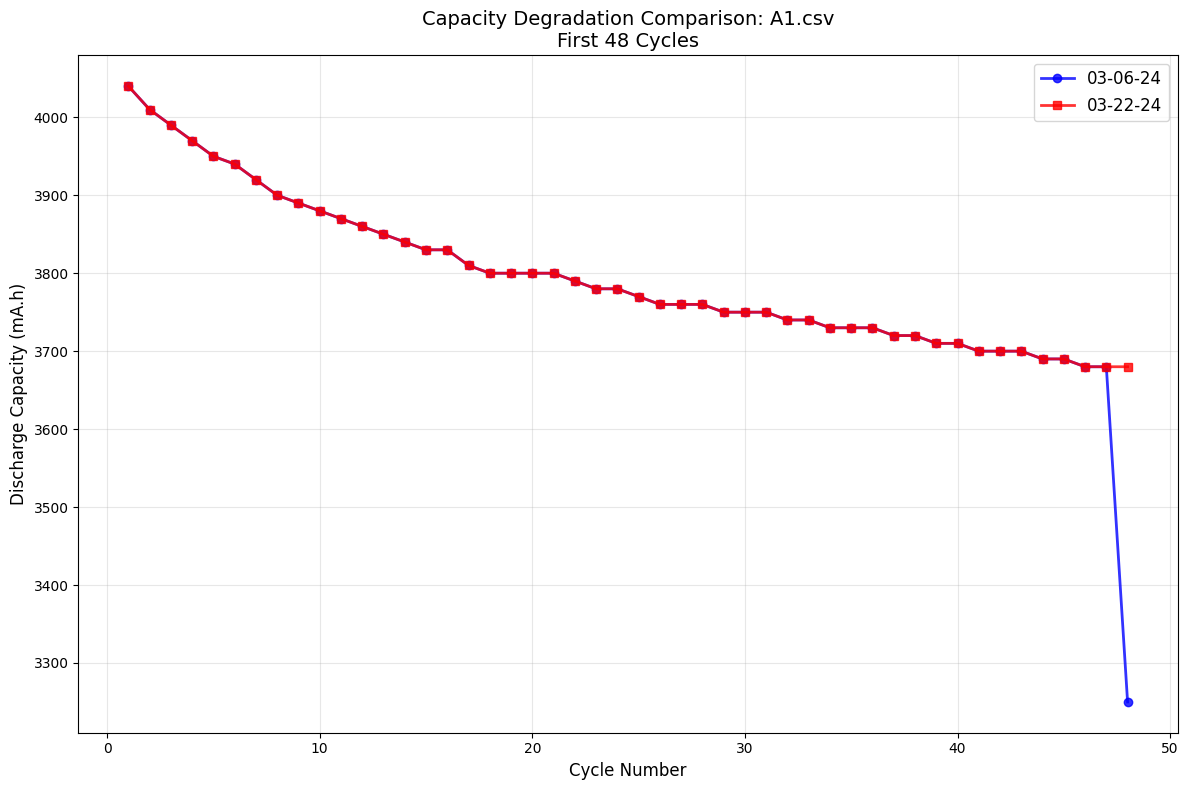


Comparison for first 48 cycles:
  Maximum capacity difference: 430.000000 mA.h
  Average capacity difference: 8.958333 mA.h
  Standard deviation of differences: 61.415239 mA.h
  ✅ DIFFERENT: Substantial differences between datasets


In [6]:
# Load A1.csv from both datasets and compare capacity degradation
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def load_and_extract_capacity(folder, filename, max_cycles=48):
    """Load data and extract capacity degradation for first N cycles"""
    # Load the data
    df = data_pipeline.load_data(folder, filename)
    
    # Get unique cycles and sort them
    cycles = sorted(df['cycle number'].unique())
    
    # Limit to first max_cycles
    cycles = cycles[:max_cycles]
    
    # Extract discharge capacity for each cycle
    capacities = []
    cycle_numbers = []
    
    for cycle in cycles:
        cycle_data = df[df['cycle number'] == cycle]
        if 'Q discharge/mA.h' in cycle_data.columns:
            # Get the last (final) discharge capacity for this cycle
            capacity = cycle_data['Q discharge/mA.h'].iloc[-1]
            capacities.append(capacity)
            cycle_numbers.append(cycle)
    
    return np.array(cycle_numbers), np.array(capacities)

# Load data from both datasets
print("Loading capacity data from both datasets...")

# Dataset 1: 03-06-24
cycles_1, capacities_1 = load_and_extract_capacity("03-06-24", "A2.csv", max_cycles=48)
print(f"03-06-24: {len(cycles_1)} cycles, capacity range {capacities_1.min():.1f}-{capacities_1.max():.1f} mA.h")

# Dataset 2: 03-22-24  
cycles_2, capacities_2 = load_and_extract_capacity("04-03-24", "A2.csv", max_cycles=48)
print(f"03-22-24: {len(cycles_2)} cycles, capacity range {capacities_2.min():.1f}-{capacities_2.max():.1f} mA.h")

# Create comparison plot
plt.figure(figsize=(12, 8))

# Plot both datasets
plt.plot(cycles_1, capacities_1, 'o-', linewidth=2, markersize=6, alpha=0.8, 
         label='03-06-24', color='blue')
plt.plot(cycles_2, capacities_2, 's-', linewidth=2, markersize=6, alpha=0.8, 
         label='04-03-24', color='red')

plt.xlabel('Cycle Number', fontsize=12)
plt.ylabel('Discharge Capacity (mA.h)', fontsize=12)
plt.title('Capacity Degradation Comparison: A1.csv\nFirst 48 Cycles', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Add some styling
plt.tight_layout()
plt.show()

# Check if they're identical
min_length = min(len(capacities_1), len(capacities_2))
if min_length > 0:
    # Compare overlapping cycles
    common_cycles = min_length
    capacity_diff = np.abs(capacities_1[:common_cycles] - capacities_2[:common_cycles])
    
    print(f"\nComparison for first {common_cycles} cycles:")
    print(f"  Maximum capacity difference: {capacity_diff.max():.6f} mA.h")
    print(f"  Average capacity difference: {capacity_diff.mean():.6f} mA.h")
    print(f"  Standard deviation of differences: {capacity_diff.std():.6f} mA.h")

else:
    print("No overlapping cycles to compare")

In [3]:
# Let's also do a detailed cycle-by-cycle comparison
print("\nCycle-by-cycle comparison (first 10 cycles):")
print("Cycle | 03-06-24 | 03-22-24 | Difference")
print("-" * 45)

for i in range(min(10, min_length)):
    cycle_num = cycles_1[i]
    cap_1 = capacities_1[i]
    cap_2 = capacities_2[i] if i < len(capacities_2) else 0
    diff = abs(cap_1 - cap_2)
    print(f"{cycle_num:5d} | {cap_1:8.1f} | {cap_2:8.1f} | {diff:10.6f}")

# Plot the differences
if min_length > 1:
    plt.figure(figsize=(10, 6))
    common_cycles = cycles_1[:min_length]
    plt.plot(common_cycles, capacity_diff, 'ro-', markersize=4)
    plt.xlabel('Cycle Number')
    plt.ylabel('Absolute Capacity Difference (mA.h)')
    plt.title('Absolute Capacity Differences Between Datasets')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')  # Log scale to see small differences
    plt.tight_layout()
    plt.show()
    
    if capacity_diff.max() < 1e-6:
        print("📊 The datasets appear to be IDENTICAL for the overlapping cycles")
    else:
        print(f"📊 Maximum difference: {capacity_diff.max():.6f} mA.h")


Cycle-by-cycle comparison (first 10 cycles):
Cycle | 03-06-24 | 03-22-24 | Difference
---------------------------------------------


ValueError: Unknown format code 'd' for object of type 'float'